In [455]:
import pandas as pd
preprocessed_data = pd.read_csv("data/input_model.csv")
preprocessed_data
# preproccesed_data

,country,year,adaptation_and_nature_solutions,climate_science_and_phenomena,energy_and_technology,extreme_weather_and_impacts,greenhouse_gases_and_emissions,policy_agreements_and_economics,total_sentences,climate_sentences_BERT,climate_sentence_ratio_BERT,renew_pct,log_gdp,vulnerability_score
0,AFG,1995,0.0,0.0,0.0,0.0,0.0,0.0,122.0,2.0,0.016393,31.8,NaN,0.648095
1,AFG,1996,0.0,0.0,0.0,0.0,0.0,0.0,86.0,1.0,0.011628,33.9,NaN,0.648263
2,AFG,1997,0.0,0.0,0.0,0.0,0.0,0.0,77.0,1.0,0.012987,36.4,NaN,0.648422
3,AFG,1998,0.0,0.0,0.0,0.0,0.0,0.0,54.0,1.0,0.018519,38.0,NaN,0.646764
4,AFG,1999,0.0,0.0,0.0,0.0,0.0,0.0,35.0,0.0,0.000000,43.4,NaN,0.645413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5657,ZWE,2020,0.0,0.0,0.0,0.0,0.0,0.0,32.0,3.0,0.093750,84.1,23.791770,0.504157
5658,ZWE,2021,0.0,0.0,0.0,0.0,0.0,0.0,40.0,13.0,0.325000,82.4,24.068642,0.510076
5659,ZWE,2022,0.0,0.0,0.0,0.0,0.0,0.0,73.0,17.0,0.232877,NaN,23.752339,0.507661
5660,ZWE,2023,0.0,0.0,0.0,0.0,0.0,0.0,55.0,17.0,0.309091,NaN,NaN,0.506783


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

def run_ols_regression(df_model, target_col, feature_cols, cluster_col="country", plot_=True, verbose=True):
    """
    OLS regression with clustured se. 
    Sometimes, not all data is present. This function will drop rows with missing values 
    """


    if verbose:
        print(f"Number of rows before possibly dropping missing values: {len(df_model)}")
    # drop rows from df_model that have missing values in target_col or feature_cols
    df_model = df_model.dropna(subset=[target_col] + feature_cols).reset_index(drop=True)
    if verbose:
        print(f"Dropped rows with missing values. Remaining rows: {len(df_model)}")
  
    # define variables to regress
    features_formula = " + ".join(feature_cols)
    formula = f"{target_col} ~ {features_formula}"

    model = smf.ols(formula=formula, data=df_model).fit(cov_type="cluster", cov_kwds={"groups": df_model[cluster_col]})

    spec_type = f"Panel (Clustered on {cluster_col})"
    print(f"\n{'='*80}")
    print(f"REGRESSION: {formula}")
    print(f"Specification: {spec_type}")
    print(f"{'='*80}")
    print(model.summary())


    if plot_:
        num_terms = len(feature_cols) + 1 
        # Dynamically size figure height based on number of terms
        fig_height = max(5, int(2.5 * ((num_terms + 1) // 2)))
        fig = plt.figure(figsize=(12, fig_height))

        sm.graphics.plot_partregress_grid(model, fig=fig)

        plot_title = f"Partial Regression Plots: {formula}\n[{spec_type}]"
        plt.suptitle(plot_title, fontsize=12, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

    return model


Number of rows before possibly dropping missing values: 5662
Dropped rows with missing values. Remaining rows: 4913

REGRESSION: renew_pct ~ log_gdp + vulnerability_score + climate_sentence_ratio_BERT
Specification: Panel (Clustered on country)
                            OLS Regression Results                            
Dep. Variable:              renew_pct   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     24.85
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           1.41e-13
Time:                        14:24:21   Log-Likelihood:                -22840.
No. Observations:                4913   AIC:                         4.569e+04
Df Residuals:                    4909   BIC:                         4.571e+04
Df Model:                           3                                         
Covariance Type:              cluster       

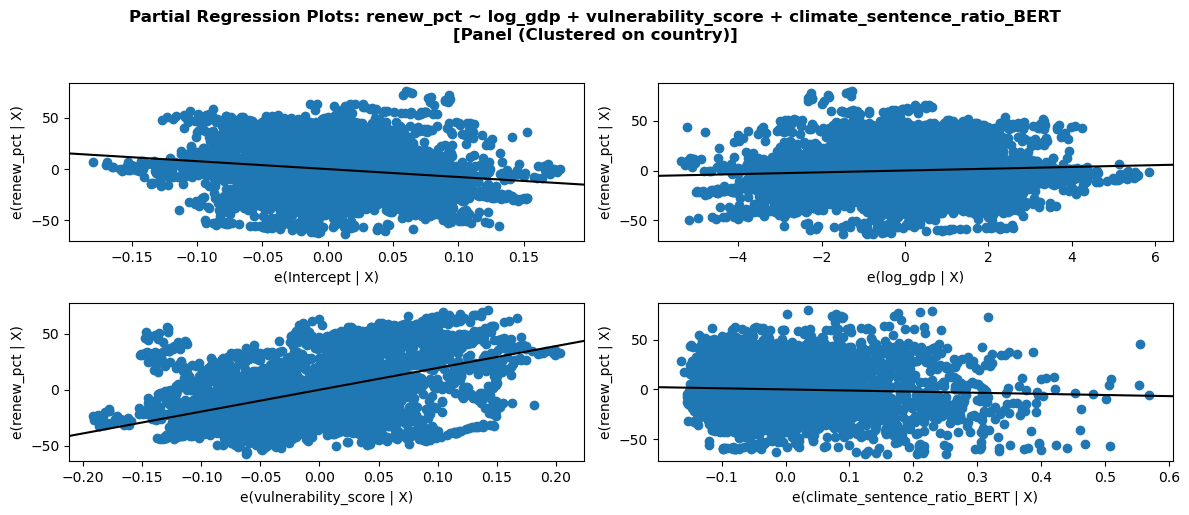

In [ ]:
FEATURE_COLS = ["log_gdp", "vulnerability_score", "climate_sentence_ratio_BERT"]
TARGET_COL = "renew_pct"
run_ols_regression(preprocessed_data, TARGET_COL, FEATURE_COLS, cluster_col="country", plot_=True)


# First impressions
---
there is not much correlation that is statistically significant. But currently we are looking at each year. However, we can look if talking at year t affects the year t+n

In [465]:
def look_forward(df_model, t):
    """
    Look at the effect of talking about climate change in year t on renewable energy adoption in year t+n. We cannot use shift because not every year is recorded for some countries
    """
    
    # Sort the dataframe by country and year
    df_model = df_model.sort_values(by=['country', 'year']).reset_index(drop=True)
    
    for t_shift in range(1, t + 1):
        df_model[f"renew_pct_t{t_shift}"] = df_model.groupby('country')['renew_pct'].shift(-t_shift)

    return df_model

t = 5
df_model = look_forward(preprocessed_data, t)
df_model
for n in range(1, t+1):
    TARGET_COL = f"renew_pct_t{n}"
    print(f"\n\nLooking at the effect of talking about climate change in year t on renewable energy adoption in year t+{n}")
    run_ols_regression(df_model, TARGET_COL, FEATURE_COLS, cluster_col="country", plot_=False)




Looking at the effect of talking about climate change in year t on renewable energy adoption in year t+1
Number of rows before possibly dropping missing values: 5662
Dropped rows with missing values. Remaining rows: 4690

REGRESSION: renew_pct_t1 ~ log_gdp + vulnerability_score + climate_sentence_ratio_BERT
Specification: Panel (Clustered on country)
                            OLS Regression Results                            
Dep. Variable:           renew_pct_t1   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     23.96
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           3.62e-13
Time:                        14:43:25   Log-Likelihood:                -21785.
No. Observations:                4690   AIC:                         4.358e+04
Df Residuals:                    4686   BIC:                         4.360e+04
Df Model:    